In [29]:
import os
import glob
import json
import numpy as np
import pandas as pd
from pathlib import Path
from PNW_cmap import PNW_cmap
import matplotlib.pyplot as plt
from vip_slap2_analysis.utils.utils import save_figure
from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.glutamate.summary import GlutamateSummary
from vip_slap2_analysis.utils.utils import normalize

import seaborn as sns
sns.set_style('white')
params = {'legend.fontsize': 'x-large',
         'axes.labelsize': 'xx-large',
         'axes.titlesize':'xx-large',
         'xtick.labelsize':'xx-large',
         'ytick.labelsize':'xx-large'}
plt.rcParams.update(params)

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
%matplotlib notebook

In [158]:
savepath = r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Data_Club\April2026\figures'

In [5]:
target_mice = [
    803496,
    804730,804733,810196,
    809047,803121,
    826033,838410,834788
]

registry = VIPSessionRegistry.from_basepath(
    r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics'
)

process_df = registry.sessions(
    subject_ids=target_mice,
    exclude_session_types=["expression_check", "volume_imaging"],
    paradigms=["change_detection_passive"],
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Loaded {len(assets)} session assets")

Loaded 56 session assets


In [6]:
mean_paths = [glob.glob(os.path.join(asset.derived_dir,'**','glutamate_mean_df.npz'),recursive=True)[0] for asset in assets]

In [9]:
act_sums = []
act_evns = []
for asset in assets:
    try:
        print(asset.session_id)
        derived_dir = asset.derived_dir / 'glutamate' /'glutamate_analysis'
        act_sum = pd.read_parquet(os.path.join(derived_dir, 'activation_summary_table.parquet'))
        act_sums.append(act_sum)
        
        act_e =  pd.read_parquet(os.path.join(derived_dir, 'activation_event_table.parquet'))
        act_evns.append(act_e)
        
    except Exception as e:
        print(f"An exception occurred for {asset.session_id}: {e}")
        

act_summary = pd.concat(act_sums)
act_events = pd.concat(act_evns)

803496_2025-07-25_13-02-10
803496_2025-07-28_08-04-39
803496_2025-07-29_13-34-35
803496_2025-07-30_10-05-23
803496_2025-07-31_09-43-28
803496_2025-08-01_13-22-49
804730_2025-07-25_14-08-35
804730_2025-07-28_13-57-34
804730_2025-07-29_14-55-04
804730_2025-07-30_11-11-11
804730_2025-07-31_11-45-27
804730_2025-08-01_14-22-38
804733_2025-07-25_15-17-00
804733_2025-07-28_19-00-06
804733_2025-07-29_16-02-24
804733_2025-07-30_12-59-44
804733_2025-07-31_13-29-01
804733_2025-08-01_15-20-32
810196_2025-07-25_16-24-20
810196_2025-07-28_19-59-05
810196_2025-07-29_17-02-41
810196_2025-07-31_08-28-08
810196_2025-07-31_14-19-46
810196_2025-08-01_16-37-27
809047_2025-10-29_10-16-32
809047_2025-10-30_10-06-43
809047_2025-10-31_12-00-50
809047_2025-11-01_17-51-59
809047_2025-11-05_10-13-00
809047_2025-11-06_11-05-31
803121_2025-10-29_11-19-29
803121_2025-10-30_11-13-32
803121_2025-10-31_13-05-26
803121_2025-11-01_19-00-21
803121_2025-11-05_11-16-57
803121_2025-11-06_12-12-23
826033_2026-02-21_09-23-34
8

In [10]:
act_summary[act_summary['stimulus_family']=='image']

,session_id,subject_id,dmd,synapse_id,stimulus_family,n_events,median_delta_auc,mean_delta_auc,effect_direction,p_value,response_class,q_value_within_synapse
0,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0000,image,2277,-20.015213,-23.085767,none,3.356907e-02,no_change,1.007072e-01
1,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0001,image,2277,11.062568,10.113008,none,1.885622e-01,no_change,3.431282e-01
2,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,image,2277,62.247024,75.345806,up,1.833899e-10,activated,5.501698e-10
3,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0003,image,2277,51.070708,94.594795,up,5.779422e-15,activated,1.733827e-14
4,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0004,image,2277,-94.736861,-159.029189,down,1.601894e-34,deactivated,4.805682e-34
...,...,...,...,...,...,...,...,...,...,...,...,...
257,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0068,image,2358,-9.735355,-21.796510,down,1.246066e-06,deactivated,3.738198e-06
258,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0069,image,2358,-17.261787,-29.570562,down,5.430057e-13,deactivated,1.629017e-12
259,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0070,image,2358,-7.591598,-3.330205,none,6.692650e-02,no_change,1.003898e-01
260,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0071,image,2358,-1.012764,-7.875426,none,3.627400e-02,no_change,5.441100e-02


In [11]:
act_events

,session_id,subject_id,dmd,synapse_id,stimulus_family,stimulus_name,stimulus_label,event_index,delta_auc,delta_mean
0,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0000,image,stimuli\images_A\imk00459.tiff,imk00459,0,-597.753021,-11.955060
1,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0001,image,stimuli\images_A\imk00459.tiff,imk00459,0,-388.249723,-7.764994
2,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,image,stimuli\images_A\imk00459.tiff,imk00459,0,-1614.649187,-32.292984
3,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0003,image,stimuli\images_A\imk00459.tiff,imk00459,0,950.246679,19.004934
4,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0004,image,stimuli\images_A\imk00459.tiff,imk00459,0,-186.733405,-3.734668
...,...,...,...,...,...,...,...,...,...,...
362707,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0068,omission,omission,omission,20,81.394568,1.627891
362708,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0069,omission,omission,omission,20,-131.200989,-2.624020
362709,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0070,omission,omission,omission,20,-20.197157,-0.403943
362710,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0071,omission,omission,omission,20,155.253537,3.105071


In [12]:
import numpy as np
import pandas as pd


def build_synapse_depth_table(assets):
    """
    Build a lookup table mapping (session_id, dmd) -> depth_um from asset metadata.

    Expects asset.metadata to contain keys like:
        'dmd1_depth', 'dmd2_depth'
    and asset.session_id to match the tables.
    """
    rows = []

    for asset in assets:
        session_id = asset.session_id
        md = getattr(asset, "metadata", None)

        if md is None:
            continue

        for dmd_num in (1, 2):
            key = f"dmd{dmd_num}_depth"
            depth = md.get(key, np.nan)

            rows.append(
                {
                    "session_id": session_id,
                    "dmd": f"DMD{dmd_num}",
                    "depth_um": depth,
                }
            )

    depth_table = pd.DataFrame(rows).drop_duplicates(subset=["session_id", "dmd"])
    return depth_table


def prepare_depth_fve_inputs(
    act_summary,
    act_events,
    assets,
    response_metric="delta_auc",
    min_images_per_synapse=2,
):
    """
    Build per-synapse and per-depth data structures for the mean-response FVE analysis.

    Parameters
    ----------
    act_summary : pd.DataFrame
        Concatenated activation_summary table across sessions.
    act_events : pd.DataFrame
        Concatenated activation_event table across sessions.
    assets : iterable
        Asset objects with .session_id and .metadata.
    response_metric : str
        Event-level response column to summarize across image repeats.
        Usually 'delta_auc'.
    min_images_per_synapse : int
        Minimum number of unique images with data required to retain a synapse.

    Returns
    -------
    out : dict
        {
            "depth_table": (session_id, dmd, depth_um),
            "activated_synapses": activated image-responsive synapses w/ depth,
            "image_means_long": one row per synapse x image,
            "synapse_metrics": one row per synapse,
            "depth_summary": one row per depth,
        }
    """

    # ------------------------------------------------------------
    # 1) Register session_id + dmd -> depth
    # ------------------------------------------------------------
    depth_table = build_synapse_depth_table(assets)

    # ------------------------------------------------------------
    # 2) Keep activated image-responsive synapses only
    # ------------------------------------------------------------
    activated_synapses = (
        act_summary.loc[
            (act_summary["stimulus_family"] == "image")
            & (act_summary["response_class"] == "activated"),
            [
                "session_id",
                "subject_id",
                "dmd",
                "synapse_id",
                "stimulus_family",
                "n_events",
                "median_delta_auc",
                "mean_delta_auc",
                "response_class",
            ],
        ]
        .drop_duplicates(subset=["session_id", "dmd", "synapse_id"])
        .merge(depth_table, on=["session_id", "dmd"], how="left")
    )

    # ------------------------------------------------------------
    # 3) Restrict event table to those synapses and image events
    # ------------------------------------------------------------
    image_events = act_events.loc[act_events["stimulus_family"] == "image"].copy()

    image_events = image_events.merge(
        activated_synapses[
            ["session_id", "dmd", "synapse_id", "subject_id", "depth_um"]
        ],
        on=["session_id", "dmd", "synapse_id"],
        how="inner",
        suffixes=("", "_act"),
    )

    # ------------------------------------------------------------
    # 4) Compute mean response to each image for each synapse
    # ------------------------------------------------------------
    group_cols = [
        "session_id",
        "subject_id",
        "dmd",
        "depth_um",
        "synapse_id",
        "stimulus_label",
    ]

    image_means_long = (
        image_events.groupby(group_cols, dropna=False)[response_metric]
        .agg(
            image_mean_response="mean",
            image_median_response="median",
            n_repeats="size",
        )
        .reset_index()
    )

    # Optional QC: require enough image categories per synapse
    n_images = (
        image_means_long.groupby(["session_id", "dmd", "synapse_id"])["stimulus_label"]
        .nunique()
        .rename("n_images_present")
        .reset_index()
    )

    image_means_long = image_means_long.merge(
        n_images, on=["session_id", "dmd", "synapse_id"], how="left"
    )

    image_means_long = image_means_long.loc[
        image_means_long["n_images_present"] >= min_images_per_synapse
    ].copy()

    # ------------------------------------------------------------
    # 5) Synapse-level metrics
    # ------------------------------------------------------------
    synapse_metrics = (
        image_means_long.groupby(
            ["session_id", "subject_id", "dmd", "depth_um", "synapse_id"],
            dropna=False,
        )["image_mean_response"]
        .agg(
            overall_mean_response="mean",   # r̄_s
            overall_median_response="median",
            image_response_var="var",       # Var_i(r_s,i)
            image_response_std="std",
            min_image_response="min",
            max_image_response="max",
            n_images_present="size",
        )
        .reset_index()
    )

    synapse_metrics["image_response_range"] = (
        synapse_metrics["max_image_response"] - synapse_metrics["min_image_response"]
    )

    synapse_metrics["cv_across_images"] = (
        synapse_metrics["image_response_std"]
        / synapse_metrics["overall_mean_response"].replace(0, np.nan)
    )

    # ------------------------------------------------------------
    # 6) Depth-level variance decomposition
    #
    # total variance: Var_{s,i}(r_s,i)
    # explained variance by synapse mean: Var_s(r̄_s)
    # FVE_mean_depth = Var_s(r̄_s) / Var_{s,i}(r_s,i)
    # ------------------------------------------------------------
    depth_total = (
        image_means_long.groupby("depth_um", dropna=False)["image_mean_response"]
        .agg(
            total_response_variance="var",
            total_response_mean="mean",
            n_synapse_image_points="size",
        )
        .reset_index()
    )

    depth_explained = (
        synapse_metrics.groupby("depth_um", dropna=False)["overall_mean_response"]
        .agg(
            explained_variance_by_synapse_mean="var",
            mean_of_synapse_means="mean",
            n_synapses="size",
        )
        .reset_index()
    )

    depth_summary = depth_total.merge(depth_explained, on="depth_um", how="outer")

    depth_summary["fve_mean_response"] = (
        depth_summary["explained_variance_by_synapse_mean"]
        / depth_summary["total_response_variance"]
    )

    depth_summary["residual_variance"] = (
        depth_summary["total_response_variance"]
        - depth_summary["explained_variance_by_synapse_mean"]
    )

    # Clean ordering
    depth_summary = depth_summary.sort_values("depth_um").reset_index(drop=True)
    synapse_metrics = synapse_metrics.sort_values(
        ["depth_um", "session_id", "dmd", "synapse_id"]
    ).reset_index(drop=True)
    image_means_long = image_means_long.sort_values(
        ["depth_um", "session_id", "dmd", "synapse_id", "stimulus_label"]
    ).reset_index(drop=True)

    return {
        "depth_table": depth_table,
        "activated_synapses": activated_synapses,
        "image_means_long": image_means_long,
        "synapse_metrics": synapse_metrics,
        "depth_summary": depth_summary,
    }

In [13]:
results = prepare_depth_fve_inputs(
    act_summary=act_summary,
    act_events=act_events,
    assets=assets,
    response_metric="delta_auc",
    min_images_per_synapse=7,   # use 7 if you want only complete image sets
)

depth_table = results["depth_table"]
activated_synapses = results["activated_synapses"]
image_means_long = results["image_means_long"]
synapse_metrics = results["synapse_metrics"]
depth_summary = results["depth_summary"]

In [80]:
act_summary

,session_id,subject_id,dmd,synapse_id,stimulus_family,n_events,median_delta_auc,mean_delta_auc,effect_direction,p_value,response_class,q_value_within_synapse
0,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0000,image,2277,-20.015213,-23.085767,none,3.356907e-02,no_change,1.007072e-01
1,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0001,image,2277,11.062568,10.113008,none,1.885622e-01,no_change,3.431282e-01
2,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0002,image,2277,62.247024,75.345806,up,1.833899e-10,activated,5.501698e-10
3,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0003,image,2277,51.070708,94.594795,up,5.779422e-15,activated,1.733827e-14
4,803496_2025-07-25_13-02-10,803496,DMD1,DMD1_syn0004,image,2277,-94.736861,-159.029189,down,1.601894e-34,deactivated,4.805682e-34
...,...,...,...,...,...,...,...,...,...,...,...,...
403,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0068,omission,21,-0.571493,-36.662196,none,7.079344e-01,no_change,7.079344e-01
404,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0069,omission,21,-19.948649,-13.116056,none,4.319115e-01,no_change,4.319115e-01
405,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0070,omission,21,-1.425935,4.064173,none,9.728584e-01,no_change,9.728584e-01
406,838410_2026-03-20_10-00-59,838410,DMD2,DMD2_syn0071,omission,21,29.892928,10.675857,none,6.091490e-01,no_change,6.091490e-01


In [81]:
act_summary[act_summary['stimulus_family']=='image'].to_csv(r"C:\Users\andrew.shelton\Downloads\activation_summary.csv")

<IPython.core.display.Javascript object>


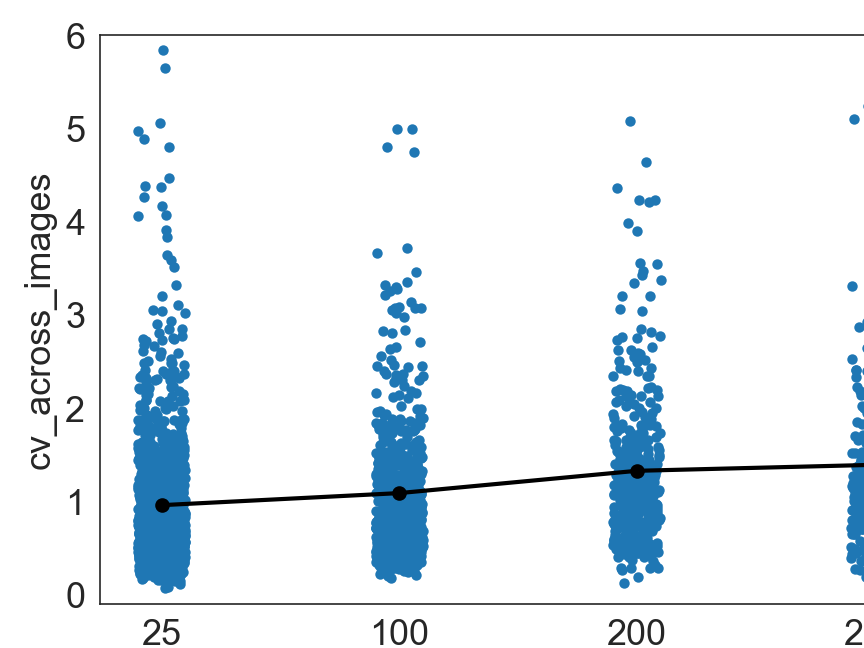

In [39]:
fig,ax=plt.subplots()

metric = 'cv_across_images'

sns.stripplot(data = synapse_metrics, y = synapse_metrics[metric],x = 'depth_um')

depths = [25,100,200,250]

means = [np.mean(synapse_metrics[metric][synapse_metrics['depth_um']==d]) for d in depths]

ax.plot(range(4),means,color='k',marker='o',lw=2,zorder=10)
ax.set_ylim(-0.1,6)
fig.tight_layout()

In [40]:
from scipy.stats import mannwhitneyu

MannwhitneyuResult(statistic=156159.0, pvalue=3.7484147857832006e-08)

In [133]:
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1) Keep only activated synapses from cumulative activation table
# ------------------------------------------------------------
activated_lookup = (
    act_summary.loc[
        (act_summary["stimulus_family"] == "image")
        & (act_summary["response_class"] == "activated"),
        ["session_id", "dmd", "synapse_id"]
    ]
    .drop_duplicates()
)

activated_sets = {
    (sid, dmd): set(df["synapse_id"].tolist())
    for (sid, dmd), df in activated_lookup.groupby(["session_id", "dmd"])
}

# ------------------------------------------------------------
# 2) Containers
# ------------------------------------------------------------
fve25 = []
fve100 = []
fve200 = []
fve250 = []

synapse_fve_rows = []

# ------------------------------------------------------------
# 3) Iterate sessions
# ------------------------------------------------------------
for i, path in enumerate(mean_paths):
    asset = assets[i]
    session_id = asset.session_id

    print(f"Processing {session_id}")

    depths = {
        "DMD1": asset.metadata.get("dmd1_depth", np.nan),
        "DMD2": asset.metadata.get("dmd2_depth", np.nan),
    }

    data = np.load(path, allow_pickle=True)["data"][0]

    for dmd in [1, 2]:
        dmd_name = f"DMD{dmd}"
        depth = depths[dmd_name]

        if dmd_name not in data:
            continue

        dmd_block = data[dmd_name]
        if "image_identity" not in dmd_block:
            continue

        activated_synapses = activated_sets.get((session_id, dmd_name), set())
        if len(activated_synapses) == 0:
            continue

        dmd_data = data[dmd_name]["image_identity"]
        image_keys = list(dmd_data.keys())
        if len(image_keys) == 0:
            continue

        # Stack image traces: (n_images, n_synapses, n_time)
        image_stack = np.stack(
            [np.asarray(dmd_data[im]["mean"]) for im in image_keys],
            axis=0
        )

        n_images, n_synapses, n_time = image_stack.shape

        # Use stored synapse_ids if available; otherwise fallback to row index
        if "synapse_ids" in dmd_block:
            synapse_ids = np.asarray(dmd_block["synapse_ids"])
        else:
            synapse_ids = np.arange(n_synapses)

        for syn_idx in range(n_synapses):
            synapse_id = synapse_ids[syn_idx]

            # Skip if this synapse was not activated
            if synapse_id not in activated_synapses:
                continue

            # shape: (n_images, n_time)
            syn_image_traces = image_stack[:, syn_idx, :]

            if np.all(np.isnan(syn_image_traces)):
                continue

            # ------------------------------------------------------------
            # Overall mean response trace across images for this synapse
            # ------------------------------------------------------------
            mean_trace = np.nanmean(syn_image_traces, axis=0)  # (n_time,)

            # ------------------------------------------------------------
            # Total variance for this synapse across all image responses
            # pooled across images and timepoints
            # ------------------------------------------------------------
            pooled = syn_image_traces[np.isfinite(syn_image_traces)]
            if pooled.size < 2:
                continue

            total_var = np.var(pooled)
            if (not np.isfinite(total_var)) or (total_var <= 0):
                continue

            # ------------------------------------------------------------
            # Image-wise FVE relative to the overall mean response
            # ------------------------------------------------------------
            image_fves = []
            for im_idx in range(n_images):
                resp = syn_image_traces[im_idx]

                valid = np.isfinite(resp) & np.isfinite(mean_trace)
                if valid.sum() < 2:
                    image_fves.append(np.nan)
                    continue

                resp_valid = resp[valid]
                mean_valid = mean_trace[valid]

                resid_var = np.var(resp_valid - mean_valid)
                fve = 1 - (resid_var / total_var)

                image_fves.append(fve)

            image_fves = np.asarray(image_fves, dtype=float)

            # Mean FVE explained by the mean across images
            syn_fve = np.nanmean(image_fves)

            synapse_fve_rows.append(
                {
                    "session_id": session_id,
                    "mean_path": str(path),
                    "dmd": dmd_name,
                    "depth_um": depth,
                    "synapse_id": synapse_id,
                    "synapse_index": syn_idx,
                    "total_var": total_var,
                    "mean_associated_fve": syn_fve,
                    "image_fves": image_fves,
                }
            )

            # Bin by depth
            if depth == 25:
                fve25.append(syn_fve)
            elif depth == 100:
                fve100.append(syn_fve)
            elif depth == 200:
                fve200.append(syn_fve)
            elif depth == 250:
                fve250.append(syn_fve)

# ------------------------------------------------------------
# 4) Convert outputs
# ------------------------------------------------------------
fve25 = np.asarray(fve25, dtype=float)
fve100 = np.asarray(fve100, dtype=float)
fve200 = np.asarray(fve200, dtype=float)
fve250 = np.asarray(fve250, dtype=float)

synapse_fve_df = pd.DataFrame(synapse_fve_rows)

fve_by_depth = {
    25: fve25,
    100: fve100,
    200: fve200,
    250: fve250,
}

Processing 803496_2025-07-25_13-02-10
Processing 803496_2025-07-28_08-04-39
Processing 803496_2025-07-29_13-34-35
Processing 803496_2025-07-30_10-05-23
Processing 803496_2025-07-31_09-43-28
Processing 803496_2025-08-01_13-22-49
Processing 804730_2025-07-25_14-08-35
Processing 804730_2025-07-28_13-57-34
Processing 804730_2025-07-29_14-55-04
Processing 804730_2025-07-30_11-11-11
Processing 804730_2025-07-31_11-45-27
Processing 804730_2025-08-01_14-22-38
Processing 804733_2025-07-25_15-17-00
Processing 804733_2025-07-28_19-00-06
Processing 804733_2025-07-29_16-02-24
Processing 804733_2025-07-30_12-59-44
Processing 804733_2025-07-31_13-29-01
Processing 804733_2025-08-01_15-20-32
Processing 810196_2025-07-25_16-24-20
Processing 810196_2025-07-28_19-59-05
Processing 810196_2025-07-29_17-02-41
Processing 810196_2025-07-31_08-28-08
Processing 810196_2025-07-31_14-19-46
Processing 810196_2025-08-01_16-37-27
Processing 809047_2025-10-29_10-16-32
Processing 809047_2025-10-30_10-06-43
Processing 8

In [134]:
depth_list = [25]*len(fve_by_depth[25]) + [100]*len(fve_by_depth[100]) + [200]*len(fve_by_depth[200]) + [250]*len(fve_by_depth[250])

fve_df = pd.DataFrame(np.array([np.concatenate(list(fve_by_depth.values())),depth_list]).T,columns=['fve','depth'])

In [135]:
cl, cmap, cp = PNW_cmap.get_PNW_cmap('Sailboat', n_colors=4)
cp

[(0.4823529411764706, 0.7372549019607844, 0.8352941176470589),
 (0.8156862745098039, 0.8862745098039215, 0.6862745098039216),
 (0.9607843137254901, 0.8588235294117647, 0.6),
 (0.9098039215686274, 0.611764705882353, 0.5058823529411764)]

In [136]:
cp = cp[::-1]

<IPython.core.display.Javascript object>


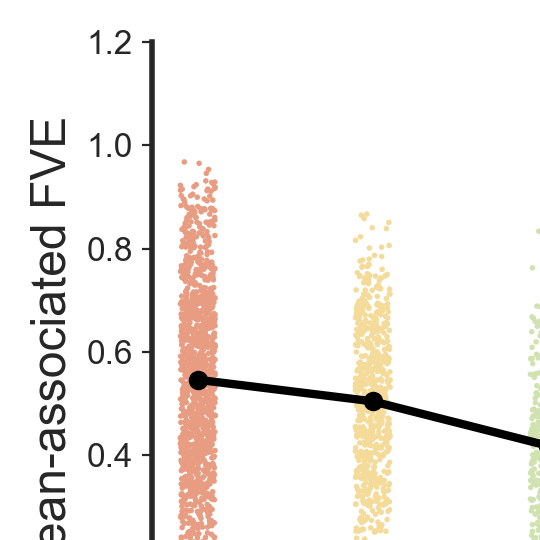

C:\Users\andrew.shelton\AppData\Local\Temp\ipykernel_21464\1087590683.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data = fve_df,x = 'depth', y = 'fve',palette=cp,size=2)


In [160]:
fig,ax=plt.subplots(figsize=(4,4))

ax.tick_params(axis='x', which='major', reset=True, top=False, labelsize=12)
ax.tick_params(axis='y', which='major', reset=True, right=False, labelsize=12)

for spine in ['left','right','top','bottom']:
    ax.spines[spine].set_linewidth(2)

sns.despine()
    
sns.stripplot(data = fve_df,x = 'depth', y = 'fve',palette=cp,size=2)

means = [np.mean(fve) for fve in [fve25,fve100,fve200,fve250]]
ax.plot(means,color='k',zorder=11,lw=3,marker='o')
ax.set_ylim(0,1.2)

ax.set_ylabel('Mean-associated FVE')
ax.set_xlabel('Depth from pia (\u03BCm)')

fig.tight_layout()
filen = 'FVE-depth'
save_figure(fig,os.path.join(savepath,filen),formats = ['.pdf','.png'],dpi=300 )

In [156]:
import itertools
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests


# ------------------------------------------------------------
# Pairwise depth comparisons
# ------------------------------------------------------------
depth_order = [25, 100, 200, 250]

pairwise_rows = []

for d1, d2 in itertools.combinations(depth_order, 2):
    x = fve_df.loc[fve_df["depth"] == d1, "fve"].dropna().to_numpy()
    y = fve_df.loc[fve_df["depth"] == d2, "fve"].dropna().to_numpy()

    if len(x) == 0 or len(y) == 0:
        continue

    stat, p = mannwhitneyu(x, y, alternative="two-sided")

    pairwise_rows.append(
        {
            "depth_1": d1,
            "depth_2": d2,
            "n_1": len(x),
            "n_2": len(y),
            "median_1": np.median(x),
            "median_2": np.median(y),
            "mean_1": np.mean(x),
            "mean_2": np.mean(y),
            "mw_u": stat,
            "p_uncorrected": p,
        }
    )

pairwise_stats = pd.DataFrame(pairwise_rows)

# ------------------------------------------------------------
# Multiple-comparisons correction
# ------------------------------------------------------------
reject, p_fdr, _, _ = multipletests(
    pairwise_stats["p_uncorrected"].values,
    alpha=0.05,
    method="fdr_bh",
)

pairwise_stats["p_fdr_bh"] = p_fdr
pairwise_stats["significant_fdr_bh"] = reject

pairwise_stats = pairwise_stats.sort_values("p_fdr_bh").reset_index(drop=True)

pairwise_stats

,depth_1,depth_2,n_1,n_2,median_1,median_2,mean_1,mean_2,mw_u,p_uncorrected,p_fdr_bh,significant_fdr_bh
0,25,200,1265,396,0.541903,0.405575,0.545958,0.418319,357306.0,1.169688e-37,7.018129e-37,True
1,100,200,656,396,0.502406,0.405575,0.504172,0.418319,174081.0,2.121433e-20,6.364300e-20,True
2,25,250,1265,341,0.541903,0.450300,0.545958,0.454452,280540.0,1.422294e-17,2.844589e-17,True
3,100,250,656,341,0.502406,0.450300,0.504172,0.454452,133771.0,3.722942e-07,5.584414e-07,True
4,25,100,1265,656,0.541903,0.502406,0.545958,0.504172,469759.0,1.968200e-06,2.361841e-06,True
5,200,250,396,341,0.405575,0.450300,0.418319,0.454452,58289.0,1.363113e-03,1.363113e-03,True
